# Defining tools

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from tavily import TavilyClient

def tavily_search_tool(query: str, max_results: int = 5, include_images: bool = False) -> list[dict]:
    # Create tavily client using api key
    api_key = os.getenv("TAVILY_API_KEY")
    client = TavilyClient(api_key=api_key)
    
    # Perform Tavily web search
    response = client.search(
        query=query,
        max_results=max_results,
        include_images=include_images
    )
    
    results = []
    
    # Loop through each search result and store title, content and url
    for item in response["results"]:
        results.append({
            "title": item["title"],
            "content": item["content"],
            "url": item["url"]
        })
    
    if include_images:
        for img_url in response["images"]:
            results.append({
                "image_url":img_url
            })
    
    return results

In [2]:
tavily_search_tool(
    query="trends in AI",
    max_results=1
)

[{'title': "What's next in AI: 7 trends to watch in 2026 - Microsoft Source",
  'content': '[Skip to main content](https://news.microsoft.com/source/features/ai/whats-next-in-ai-7-trends-to-watch-in-2026/)[![Image 1: Microsoft](https://uhf.microsoft.com/images/microsoft/RE1Mu3b.png)](https://www.microsoft.com/)[Source](https://news.microsoft.com/source)[Signal blog](https://news.microsoft.com/signal/)[Official Microsoft Blog](https://blogs.microsoft.com/)[Microsoft On The Issues](https://blogs.microsoft.com/on-the-issues/)[Asia](https://news.microsoft.com/apac/)[Canada](https://news.microsoft.com/source/canada/)[Europe, Middle East and Africa](https://news.microsoft.com/europe/)[Latin America](https://news.microsoft.com/es-xl/)[The Code of Us](https://news.microsoft.com/codeofus)[Conexiones](https://blogs.microsoft.com/conexiones/)[What\'s new today](https://news.microsoft.com/signal/)[AI](https://news.microsoft.com/source/topics/ai/)[Innovation](https://news.microsoft.com/source/topic

In [2]:
import pandas as pd 

def product_catalog_tool() -> list[dict]:
    df = pd.read_csv('inv_data.csv')
    return df.to_dict(orient="records")

In [3]:
product_catalog_tool()

[{'name': 'Aviator',
  'item_id': 'SG001',
  'description': 'Originally designed for pilots, these teardrop-shaped lenses with thin metal frames offer timeless appeal. The large lenses provide excellent coverage while the lightweight construction ensures comfort during long wear.',
  'quantity_in_stock': 23,
  'price': 103},
 {'name': 'Wayfarer',
  'item_id': 'SG002',
  'description': 'Featuring thick, angular frames that make a statement, these sunglasses combine retro charm with modern edge. The rectangular lenses and sturdy acetate construction create a confident look.',
  'quantity_in_stock': 6,
  'price': 92},
 {'name': 'Mystique',
  'item_id': 'SG003',
  'description': 'Inspired by 1950s glamour, these frames sweep upward at the outer corners to create an elegant, feminine silhouette. The subtle curves and often embellished temples add sophistication to any outfit.',
  'quantity_in_stock': 3,
  'price': 88},
 {'name': 'Sport',
  'item_id': 'SG004',
  'description': 'Designed for 

In [4]:
def get_available_tools():
    return [
        {
            "type": "function",
            "function": {
                "name": "tavily_search_tool",
                "description": "Perform web search for sunglasses trends using Tavily.",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "query": {"type": "string", "description": "Search query"},
                        "max_results": {"type": "integer", "default": 5},
                        "include_images": {"type": "boolean", "default": False}
                    },
                    "required": ["query"]
                }
            }
        },
        {
            "type": "function",
            "function": {
                "name": "product_catalog_tool",
                "description": "Get sunglasses products from internal inventory.",
            }
        }
    ]

In [5]:
import json

def handle_tool_call(tool_call):
    function_name = tool_call.function.name
    arguments = json.loads(tool_call.function.arguments)

    tools_map = {
        "tavily_search_tool": tavily_search_tool,
        "product_catalog_tool": product_catalog_tool,
    }

    return tools_map[function_name](**arguments)

In [6]:
def create_tool_response_message(tool_call, tool_result):
    return {
        "role": "tool",
        "tool_call_id": tool_call.id,
        "name": tool_call.function.name,
        "content": json.dumps(tool_result)
    }

# Building the Agent

### Market research agent

In [7]:
import aisuite
client = aisuite.Client()
openai_api_key = os.getenv("OPENAI_API_KEY")

In [ ]:
from datetime import datetime

def market_research_agent(return_messages: bool = False):
    prompt = f"""
    You are a fashion market research agent tasked with preparing a trend analysis for a summer sunglasses campaign.

    Your goal:
    1. Explore current fashion trends related to sunglasses using web search.
    2. Review the internal product catalog to identify items that align with those trends.
    3. Recommend one or more products from the catalog that best match emerging trends.
    4. If needed, today date is {datetime.now().strftime("%Y-%m-%d")}.

    You can call the following tools:
    - tavily_search_tool: to discover external web trends.
    - product_catalog_tool: to inspect the internal sunglasses catalog.

    Once your analysis is complete, summarize:
    - The top 2-3 trends you found.
    - The product(s) from the catalog that fit these trends.
    - A justification of why they are a good fit for the summer campaign.
    """
    
    messages = [
        {
            "role":"user",
            "content":prompt
        }
    ]
    tools_desc = get_available_tools()
    
    # Generate response
    while True:
        res = client.chat.completions.create(
            model="openai:o4-mini",
            messages=messages,
            tools=tools_desc,
            tool_choice="auto"
        )
        msg = res.choices[0].message
        
        if msg.content:
            print(msg.content)
            return (msg.content, messages) if return_messages else msg.content
        
        if msg.tool_calls:
            for tool_call in msg.tool_calls:
                print(tool_call.function.name)
                print(tool_call.function.arguments)
                result = handle_tool_call(tool_call)
                print(result)
                messages.append(msg)
                messages.append(create_tool_response_message(tool_call, result))
        

In [9]:
market_result = market_research_agent()

tavily_search_tool
{"query":"2026 summer sunglasses fashion trends","max_results":5,"include_images":false}
[{'title': 'Sunglasses Trends for Summer 2026: What Styles Everyone Will Be ...', 'content': '# Sunglasses Trends for Summer 2026: What Styles Everyone Will Be Wearing. Trending sunglasses styles for Summer 2026 featuring oversized frames, tinted lenses, cat-eye designs, and wraparound sunglasses - Mass Vision. Summer 2026 is shaping up to be a standout season for sunglasses. Whether you’re styling beach looks, outdoor adventures, or everyday outfits, these are the **top sunglasses trends dominating Summer 2026**. Oversized sunglasses continue to lead the way this summer. Shield sunglasses and wraparound frames with a single continuous lens are everywhere this summer. Classic sunglasses shapes are being reimagined for Summer 2026. Cat-eye sunglasses remain a summer favorite, especially in bold, angular designs. Beyond frame shape, color is playing a huge role in 2026 sunglasses t

### Graphic designer agent

In [50]:
import re
import json
import openai
import requests
from PIL import Image
from io import BytesIO


def graphic_designer_agent(trend_insights: str, caption_style: str = "short punchy", size: str = "1024x1024") -> dict:
    
    # 1. Generate prompt and caption
    system_message = (
        "You are a visual marketing assistant. Based on the input trend insights, "
        "write a creative and visual prompt for an AI image generation model, and also a short caption."
    )
    
    user_prompt = f"""
    Trend insights:
    {trend_insights}

    Please output:
    1. A vivid, descriptive prompt to guide image generation.
    2. A marketing caption in style: {caption_style}.

    Respond in this format:
    {{"prompt": "...", "caption": "..."}}
    """
    
    chat_response = client.chat.completions.create(
        model="openai:o4-mini",
        messages=[
            {"role":"system", "content":system_message},
            {"role":"user", "content": user_prompt}
        ]
    )
    
    content = chat_response.choices[0].message.content.strip()
    match = re.search(r'\{.*\}', content, re.DOTALL)
    parsed = json.loads(match.group(0) if match else {"error":"No JSON returned", "raw":content})
    prompt = parsed["prompt"]
    caption = parsed["caption"]
    
    # 2. Generate image
    openai_client = openai.OpenAI()
    image_response = openai_client.images.generate(
        model="dall-e-3",
        prompt=prompt,
        size=size,
        quality="standard",
        n=1,
        response_format="url"
    )
    image_url = image_response.data[0].url
    
    # 3. Save image locally
    img_bytes = requests.get(image_url).content
    img = Image.open(BytesIO(img_bytes))
    filename = os.path.basename(image_url.split("?")[0])
    image_path = filename
    img.save(image_path)
    
    return{
        "image_url":image_url,
        "prompt":prompt,
        "caption":caption,
        "image_path":image_path
    }

In [11]:
graphic_result = graphic_designer_agent(
    trend_insights=market_result
)

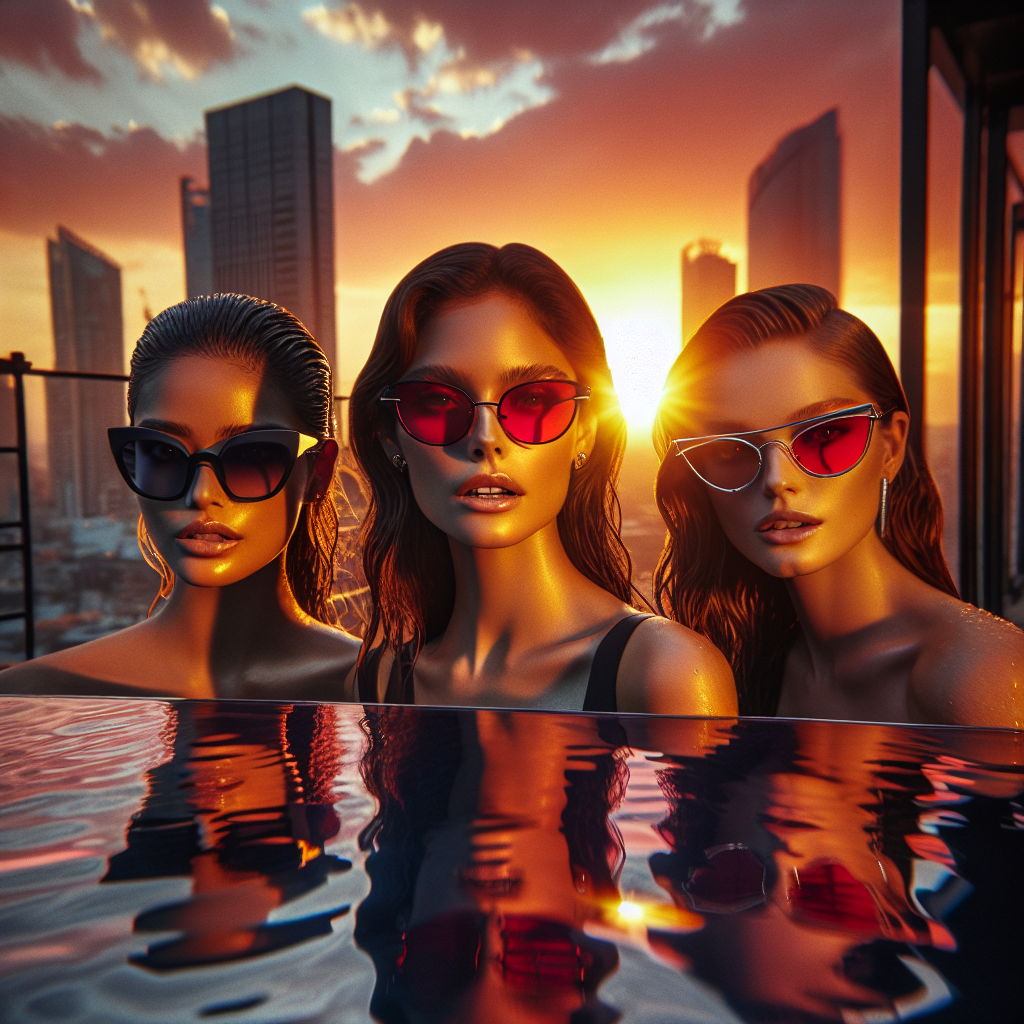

In [12]:
from IPython.display import Image
Image(graphic_result["image_path"])

### Copywriter agent

In [ ]:
import base64

def copywriter_agent(image_path: str, trend_summary: str) -> dict:
    
    # 1. Open image file as base64
    with open(image_path, "rb") as f:
        img_bytes = f.read()
    b64_img = base64.b64encode(img_bytes).decode("utf-8")
    
    messages = [
        {
            "role": "system",
            "content": "You are a copywriter that creates elegant campaign quotes based on an image and a marketing trend summary."
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{b64_img}",
                        "detail": "auto"
                    }
                },
                {
                    "type": "text",
                    "text": f"""
                    Here is a visual marketing image and a trend analysis:

                    Trend summary:
                    \"\"\"{trend_summary}\"\"\"

                    Please return a JSON object like:
                    {{
                    "quote": "A short, elegant campaign phrase (max 12 words)",
                    "justification": "Why this quote matches the image and trend"
                    }}"""
                }
            ]
        }
    ]
    
    # 2. Generate response
    response = client.chat.completions.create(
        model="openai:o4-mini",
        messages=messages
    )
    
    content = response.choices[0].message.content.strip()
    print(content)
    
    # 3. Return parsed json
    match = re.search(r'\{.*\}', content, re.DOTALL)
    parsed = json.loads(match.group(0)) if match else {"error":"No valid JSON returned"}
    parsed["image_path"] = image_path
    return parsed

In [16]:
copywriter_result = copywriter_agent(
    image_path=graphic_result["image_path"],
    trend_summary=market_result,
)

{
  "quote": "Iconic Silhouettes, Infinite Summer",
  "justification": "This phrase highlights the three distinct frame styles—wrap-around sport, bold cat-eye, and sleek aviator—set against a glowing sunset poolside scene, perfectly capturing Summer 2026’s trend for performance, glamour, and timeless elegance."
}


# Packaging Agent

In [ ]:
def packaging_agent(trend_summary: str, image_url: str, quote: str, justification: str, output_path: str="campaign_summary.md") -> str:
    # 1. Generate response
    response = client.chat.completions.create(
        model="openai:o4-mini",
        messages=[
            {
                "role":"system",
                "content":"You are a marketing communication expert writing elegant campaign summaries for executives."
            },
            {
                "role":"user",
                "content": f"""
                Please rewrite the following trend summary to be clear, professional, and engaging for a CEO audience:
                \"\"\"{trend_summary.strip()}\"\"\"
                """
            }
        ]
    )
    summary = response.choices[0].message.content.strip()
    
    # 2. Generate final markdown
    styled_image_html = f'<img src="{image_url}" width="700">'
    
    markdown_content = f"""# 🕶️ Summer Sunglasses Campaign - Executive Summary

## 📊 Refined Trend Insights
{summary}

## 🎯 Campaign Visual
{styled_image_html}

## ✍️ Campaign Quote
{quote.strip()}

## ✅ Why This Works
{justification.strip()}
"""
    
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(markdown_content)
    
    return output_path

In [46]:
packaging_result = packaging_agent(
    trend_summary=market_result,
    image_url=graphic_result["image_url"],
    quote=copywriter_result["quote"],
    justification=copywriter_result["justification"],
    output_path=f"campaign_summary_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.md"
)

In [47]:
from IPython.display import Markdown, display
with open(packaging_result, "r", encoding="utf-8") as f:
    md_content = f.read()

display(Markdown(md_content))

# 🕶️ Summer Sunglasses Campaign - Executive Summary

## 📊 Refined Trend Insights
Executive Summary: Summer 2026 Eyewear Trends & Campaign Opportunity

1. Market Trends  
– Oversized “Shield” & Wrap-Around Frames  
  • Consumer Insight: Sport-inspired, single-lens silhouettes are gaining traction among active and streetwear audiences seeking bold protection and performance.  
– Bold Cat-Eye & Statement Retro Shapes  
  • Consumer Insight: Modernized 1950s-style upswept frames deliver a fashion-forward statement for customers who prize self-expression.  
– Polished Metal Frames & Timeless Classics  
  • Consumer Insight: Sleek aviators and wire-frame squares appeal to professionals and style purists desiring understated sophistication.

2. Recommended Product Capsule  
– SG004 “Sport” Wrap-Around  
  • Delivers full coverage, wind protection and a distinctive, athletic silhouette.  
– SG003 “Mystique” Cat-Eye  
  • Captures the renewed cat-eye craze with an angular, upswept design for high-impact glamour.  
– SG001 “Aviator” Metal-Frame  
  • Offers a refined, futuristic edge through thinline metal construction and classic teardrop lenses.

3. Strategic Rationale for the Summer Campaign  
– Full-Spectrum Appeal: These three styles span performance, fashion and timeless elegance—enabling us to address multiple consumer segments with one cohesive capsule.  
– Brand Positioning: Reinforces our reputation for innovation and design leadership, from high-tech activewear to elevated lifestyle accessories.  
– Growth Potential: By marketing this trio together, we maximize cross-sell opportunities, streamline inventory, and drive margin-rich full-price sell-through.

Next Steps  
– Finalize creative assets and media plan for a June launch.  
– Align retail partners on in-store displays emphasizing the “Function + Fashion” narrative.  
– Activate targeted digital, social and influencer campaigns to showcase each style’s unique story.

## 🎯 Campaign Visual
<img src="https://oaidalleapiprodscus.blob.core.windows.net/private/org-5sn8H4QG0WTtBDck60RwQTRt/user-RkMjllhmHjvDEbHHW7SC3wOw/img-aAzk3hqrAAm8UvYKM2c77QHv.png?st=2026-04-21T17%3A47%3A41Z&se=2026-04-21T19%3A47%3A41Z&sp=r&sv=2026-02-06&sr=b&rscd=inline&rsct=image/png&skoid=35890473-cca8-4a54-8305-05a39e0bc9c3&sktid=a48cca56-e6da-484e-a814-9c849652bcb3&skt=2026-04-21T17%3A29%3A17Z&ske=2026-04-22T17%3A29%3A17Z&sks=b&skv=2026-02-06&sig=r2bLFHOalAl95DAsKYmcJDpBiI/RH0e3xatbrCRw4z0%3D" width="700">

## ✍️ Campaign Quote
Iconic Silhouettes, Infinite Summer

## ✅ Why This Works
This phrase highlights the three distinct frame styles—wrap-around sport, bold cat-eye, and sleek aviator—set against a glowing sunset poolside scene, perfectly capturing Summer 2026’s trend for performance, glamour, and timeless elegance.


# Full pipeline

In [48]:
def run_sunglasses_campaign_pipeline(output_path: str = "campaign_summary.md") -> dict:
    # 1. Run market research agent
    trend_summary = market_research_agent()
    print("Market research completed")
    
    # 2. Generate image + caption
    visual_result = graphic_designer_agent(trend_insights=trend_summary)
    image_path = visual_result["image_path"]
    print("Image generated")
    
    # 3. Generate quote based on image + trends
    quote_result = copywriter_agent(
        image_path=image_path,
        trend_summary=trend_summary
    )
    print("Quote created")
    
    # 4. Generate markdown result
    md_path = packaging_agent(
        trend_summary=trend_summary,
        image_url=image_path,
        quote=quote_result["quote"],
        justification=quote_result["justification"],
        output_path=f"campaign_summary_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.md"
    )
    print(f"Report generated: {md_path}")
    
    return {
        "trend_summary": trend_summary,
        "visual": visual_result,
        "quote": quote_result,
        "markdown_path": md_path
    }

In [51]:
results = run_sunglasses_campaign_pipeline()

tavily_search_tool
{"query":"2026 summer sunglasses fashion trends","max_results":5,"include_images":false}
[{'title': 'Sunglasses Trends for Summer 2026: What Styles Everyone Will Be ...', 'content': '# Sunglasses Trends for Summer 2026: What Styles Everyone Will Be Wearing. Trending sunglasses styles for Summer 2026 featuring oversized frames, tinted lenses, cat-eye designs, and wraparound sunglasses - Mass Vision. Summer 2026 is shaping up to be a standout season for sunglasses. Whether you’re styling beach looks, outdoor adventures, or everyday outfits, these are the **top sunglasses trends dominating Summer 2026**. Oversized sunglasses continue to lead the way this summer. Shield sunglasses and wraparound frames with a single continuous lens are everywhere this summer. Classic sunglasses shapes are being reimagined for Summer 2026. Cat-eye sunglasses remain a summer favorite, especially in bold, angular designs. Beyond frame shape, color is playing a huge role in 2026 sunglasses t

In [53]:
with open(results["markdown_path"], "r", encoding="utf-8") as f:
    md_content = f.read()

display(Markdown(md_content))

# 🕶️ Summer Sunglasses Campaign - Executive Summary

## 📊 Refined Trend Insights
Executive Summary: Summer 2026 Sunglasses Campaign

1. Market Trends  
- Futuristic Sport: Oversized, single-lens shield and wraparound frames that blend maximal coverage with a modern athletic edge.  
- Sculptural Glamour: Pronounced cat-eye and butterfly shapes that function as statement “jewelry,” offering bold angles and upswept silhouettes.  
- Modern Aviator: Timeless metal frames updated with slim profiles and gradient or tinted lenses for subtle personalization.

2. Curated Product Lineup  
- Sport (SG004)  
  • Aligns with the oversized shield trend via a seamless, single-lens design.  
  • Lightweight construction and rubber grips reinforce performance-driven comfort and style.  
- Mystique (SG003)  
  • Embodies sculptural glamour through its dramatic cat-eye shape and elegantly curved temples.  
  • Appeals to customers seeking high-impact, feminine statement eyewear.  
- Aviator (SG001)  
  • Delivers modern aviator appeal with a classic metal frame and optional gradient/tinted lenses.  
  • Proven bestseller with all-day comfort, reinforcing our core product heritage.

3. Strategic Rationale  
- Trend Coverage: The three styles span “sporty futurism,” “statement glamour,” and “timeless classic,” ensuring full-spectrum seasonal relevance.  
- Cross-Channel Storytelling: Launch Sport with athleisure visuals; Mystique through high-fashion editorials; Aviator in lifestyle and travel contexts.  
- Inventory-Driven Promotions: Stock levels (11 Sport, 3 Mystique, 23 Aviator) support tiered initiatives—limited Mystique drops to heighten urgency and broader availability for core Aviator styles.

By leveraging our best-selling silhouettes against Summer 2026’s defining eyewear trends, this campaign promises a cohesive message, broad consumer appeal, and optimized sell-through potential.

## 🎯 Campaign Visual
<img src="img-gg1NkxOesaSKxVDpayBxZqN0.png" width="700">

## ✍️ Campaign Quote
Race into Tomorrow with Futuristic Shields and Sculptural Glamour

## ✅ Why This Works
This phrase captures the campaign’s sporty-futurism (the neon-lit runner), the oversized shield trend (the sleek single-lens eyewear), and the statement sculptural elegance of the cat-eye aesthetic—echoing both the image’s high-tech visuals and Summer 2026’s top eyewear trends.
